Section 1: Setup and Initial Data Load
The goal here is to load the data and get a first look at its structure.

In [1]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set some plotting styles for better visuals
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Cell 2: Load the dataset
# We'll load the raw data from the data directory
DATA_PATH = '../data/retailrocket/events.csv' # Use relative path from the notebooks/ dir
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 2756101 rows and 5 columns.


In [ ]:
# Cell 3: Initial inspection
print("--- First 5 rows ---")
print(df.head())

print("\n--- Data types and non-null counts ---")
df.info()

print("\n--- Basic statistics for numerical columns ---")
print(df.describe())

--- First 5 rows ---
       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN

--- Data types and non-null counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB

--- Basic statistics for numerical columns ---
          timestamp     visitorid        itemid  transactionid
count  2.756101e+06  2.756101e+06  2.756101e+06   22457.000000
mean   1.436424e+12  7.019229e+05  2.349225e+05    

Section 2: Feature Engineering - "Session Velocity"
This is the most important part. Our goal is to create a feature that captures user behavior intensity. A bot will likely have a much higher "session velocity" than a human.

In [4]:
# Cell 4: Convert timestamp and sort
# The timestamp is in milliseconds, let's convert it to a datetime object
df['timestamp_dt'] = pd.to_datetime(df['timestamp'], unit='ms')

# Sort the data chronologically for each user. This is crucial for session analysis.
df_sorted = df.sort_values(by=['visitorid', 'timestamp_dt']).reset_index(drop=True)

print("Timestamp converted and data sorted.")
print(df_sorted[['visitorid', 'timestamp_dt']].head())


Timestamp converted and data sorted.
   visitorid            timestamp_dt
0          0 2015-09-11 20:49:49.439
1          0 2015-09-11 20:52:39.591
2          0 2015-09-11 20:55:17.175
3          1 2015-08-13 17:46:06.444
4          2 2015-08-07 17:51:44.567


In [5]:
# Cell 5: Calculate time difference between events
# We'll calculate the time delta between a user's consecutive events.
# A very small delta indicates rapid-fire actions.
df_sorted['time_since_last_event_sec'] = df_sorted.groupby('visitorid')['timestamp_dt'].diff().dt.total_seconds()

# The first event for each user will have a NaN delta. We can fill it with a large number
# to signify it's the start of a session.
df_sorted['time_since_last_event_sec'] = df_sorted['time_since_last_event_sec'].fillna(3600) # Fill with 1 hour

print("Time difference calculated.")
print(df_sorted[['visitorid', 'timestamp_dt', 'time_since_last_event_sec']].head(10))


Time difference calculated.
   visitorid            timestamp_dt  time_since_last_event_sec
0          0 2015-09-11 20:49:49.439                   3600.000
1          0 2015-09-11 20:52:39.591                    170.152
2          0 2015-09-11 20:55:17.175                    157.584
3          1 2015-08-13 17:46:06.444                   3600.000
4          2 2015-08-07 17:51:44.567                   3600.000
5          2 2015-08-07 17:53:33.790                    109.223
6          2 2015-08-07 17:56:52.664                    198.874
7          2 2015-08-07 18:01:08.920                    256.256
8          2 2015-08-07 18:08:25.669                    436.749
9          2 2015-08-07 18:17:24.375                    538.706


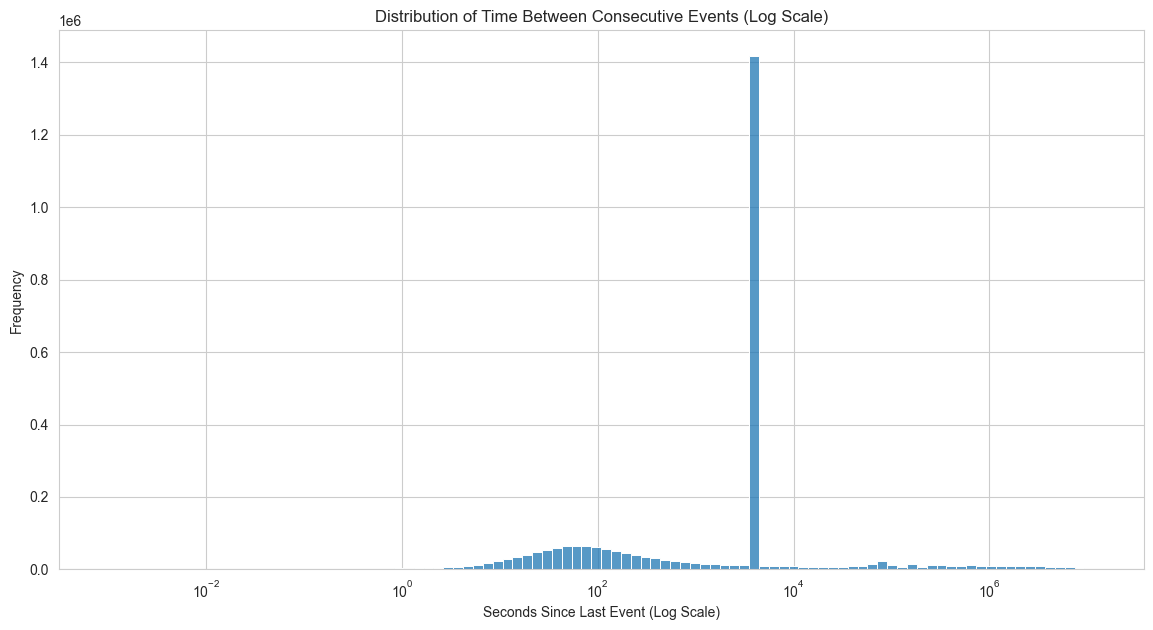

In [6]:
# Cell 6: Plot the distribution of time deltas
# Since the values can be very skewed (bots vs. humans), a log scale is essential.
plt.figure(figsize=(14, 7))
sns.histplot(data=df_sorted, x='time_since_last_event_sec', bins=100, log_scale=True)
plt.title('Distribution of Time Between Consecutive Events (Log Scale)')
plt.xlabel('Seconds Since Last Event (Log Scale)')
plt.ylabel('Frequency')
plt.show()


Number of events occurring less than 1 second after the previous one: 16835
Number of unique users responsible for these events: 8536


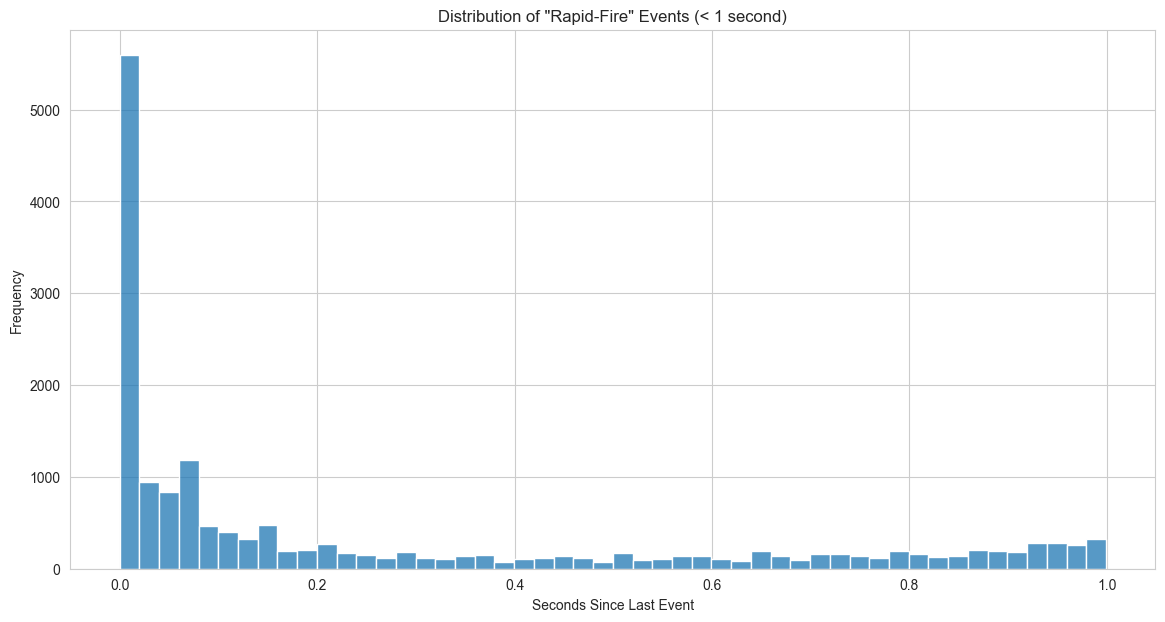

In [7]:
# Cell 7: Zoom in on the suspicious events
# Let's look at events that happen within 1 second of each other.
rapid_fire_events = df_sorted[df_sorted['time_since_last_event_sec'] < 1]

print(f"Number of events occurring less than 1 second after the previous one: {len(rapid_fire_events)}")
print(f"Number of unique users responsible for these events: {rapid_fire_events['visitorid'].nunique()}")

# Let's look at the distribution for these users
plt.figure(figsize=(14, 7))
sns.histplot(data=rapid_fire_events, x='time_since_last_event_sec', bins=50)
plt.title('Distribution of "Rapid-Fire" Events (< 1 second)')
plt.xlabel('Seconds Since Last Event')
plt.ylabel('Frequency')
plt.show()
